# Simplified EEG–BI Respiration Check

Purpose: first answer one basic question:

**Does low-frequency EEG activity from Fp1/Fp2 line up with BI-derived breathing?**

This notebook intentionally leaves out PAC, bycycle, advanced ICA interpretation, and extra metrics until the time alignment is clear.

In [93]:
# Cell 1 — Imports

import sqlite3
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
from scipy.stats import pearsonr

print("Cell 1 complete: imports loaded")

Cell 1 complete: imports loaded


In [94]:
# Cell 2 — File paths

# EEG SQLite database file
eeg_db_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/subj-1_ses-S001_task-breathing_ppg_sarah_test_run-001_20010128_225732_eeg.db"

# EmotiBit CSV file
ppg_csv_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686.csv"

# EmotiBit metadata JSON
info_json_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686_info.json"

# EEG sampling rate
fs_eeg = 250

print("Cell 2 complete: paths set")

print("\nEEG DB:")
print(eeg_db_path)

print("\nPPG CSV:")
print(ppg_csv_path)

print("\nEmotiBit JSON:")
print(info_json_path)

print("\nEEG sampling rate:")
print(fs_eeg)

Cell 2 complete: paths set

EEG DB:
/Users/sarah-rosemay/Documents/EEG_data/Combo test/subj-1_ses-S001_task-breathing_ppg_sarah_test_run-001_20010128_225732_eeg.db

PPG CSV:
/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686.csv

EmotiBit JSON:
/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686_info.json

EEG sampling rate:
250


In [95]:
# Cell 3 — Load EEG database and inspect tables

# Connect to SQLite database
conn = sqlite3.connect(eeg_db_path)

# Show table names
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Available tables:")
print(tables)

# Find the EEG data table automatically
data_table = [t for t in tables["name"] if t.startswith("data_")][0]

print("\nUsing EEG data table:")
print(data_table)

# Load EEG chunks
# Important: table name needs quotes because it contains hyphens
df = pd.read_sql_query(f'SELECT * FROM "{data_table}"', conn)

print("\nLoaded EEG dataframe shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst rows:")
display(df.head())

Available tables:
                                               name
0         data_87d03f26-0f33-4e1d-a259-2181ccc29071
1         meta_87d03f26-0f33-4e1d-a259-2181ccc29071
2  annotations_87d03f26-0f33-4e1d-a259-2181ccc29071

Using EEG data table:
data_87d03f26-0f33-4e1d-a259-2181ccc29071

Loaded EEG dataframe shape:
(3772, 3)

Columns:
Index(['data', 'time', 'local_clock'], dtype='object')

First rows:


,data,time,local_clock
0,"b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...","b""\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fort...",2.415507e+06
1,"b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...","b""\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fort...",2.415508e+06
2,"b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...","b""\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fort...",2.415508e+06
3,"b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...","b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...",2.415508e+06
4,"b""\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fort...","b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...",2.415508e+06


Number of EEG chunks: 3772

Cell 4 complete
Fp1 shape: (133600,)
Fp2 shape: (133600,)

Fp1 stats:
min: -0.562896625
max: 0.5625
std: 0.08383600370285307

Fp2 stats:
min: -0.3087373125
max: 0.5625
std: 0.10128420740248914


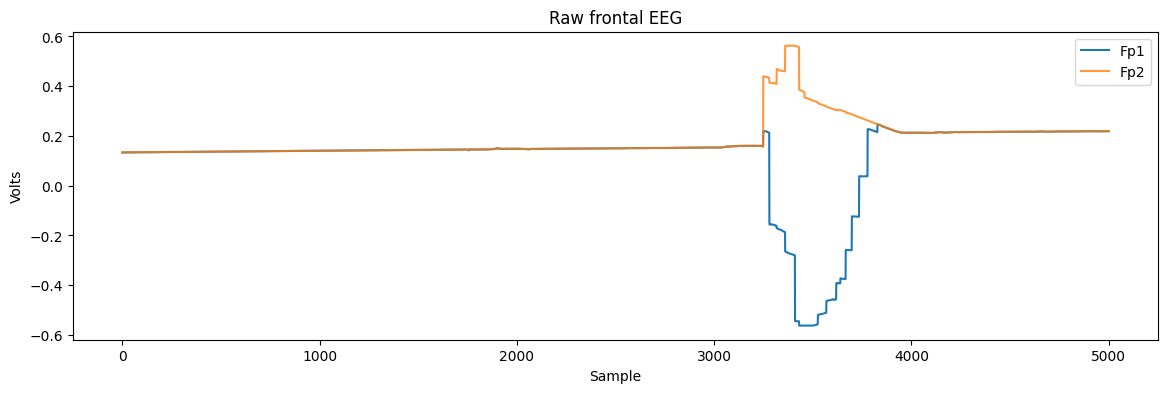

In [96]:
# Cell 4 — Load EEG

fp1_list = []
fp2_list = []

print("Number of EEG chunks:", len(df))

for i, row in df.iterrows():

    try:
        # Convert byte blob back into numpy array
        chunk = np.load(BytesIO(row["data"]), allow_pickle=True)

        # Expected shape:
        # channels x samples
        # O1, O2, Fp2, Fp1, Sample, Streaming, Battery

        # Extract frontal channels
        fp2_list.append(chunk[2])
        fp1_list.append(chunk[3])

    except Exception as e:
        print(f"Skipping chunk {i} because of error:")
        print(e)

# Concatenate all chunks
fp1 = np.concatenate(fp1_list)
fp2 = np.concatenate(fp2_list)

# Convert microvolts -> volts
fp1 = fp1 / 1e6
fp2 = fp2 / 1e6

print("\nCell 4 complete")
print("Fp1 shape:", fp1.shape)
print("Fp2 shape:", fp2.shape)

print("\nFp1 stats:")
print("min:", np.min(fp1))
print("max:", np.max(fp1))
print("std:", np.std(fp1))

print("\nFp2 stats:")
print("min:", np.min(fp2))
print("max:", np.max(fp2))
print("std:", np.std(fp2))

# Quick visualization
plt.figure(figsize=(14, 4))
plt.plot(fp1[:5000], label="Fp1")
plt.plot(fp2[:5000], label="Fp2", alpha=0.8)
plt.title("Raw frontal EEG")
plt.xlabel("Sample")
plt.ylabel("Volts")
plt.legend()
plt.show()

Cell 5 complete
fp1_breath finite: 133600 / 133600
fp2_breath finite: 133600 / 133600
fp1_breath std: 0.028035434537863942
fp2_breath std: 0.00439776804928903


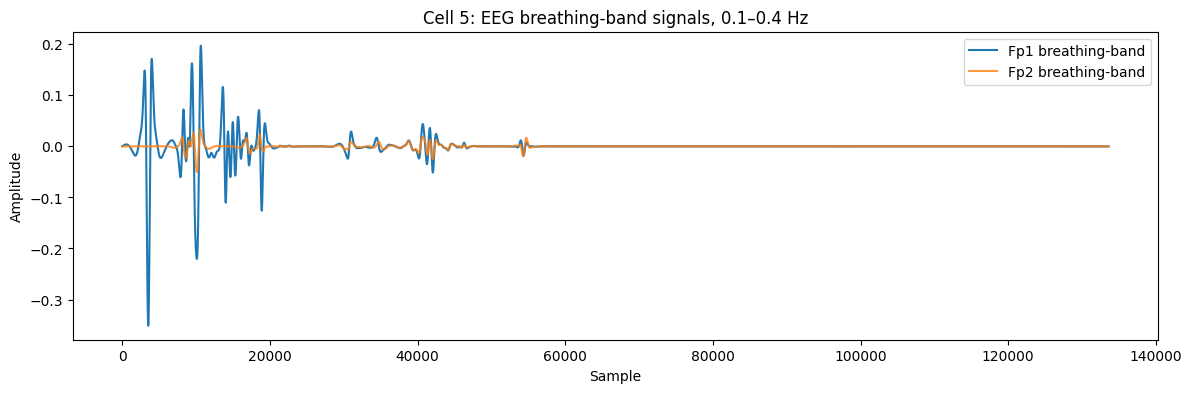

In [97]:
# Cell 5 — Filter Fp1/Fp2 into breathing band



def clean_signal_before_filter(x):
    x = np.asarray(x, dtype=float)

    # Replace bad values with NaN
    x[~np.isfinite(x)] = np.nan

    # Interpolate over NaNs
    good = np.isfinite(x)

    if good.sum() < 10:
        raise ValueError("Not enough good EEG samples to filter.")

    x[~good] = np.interp(
        np.flatnonzero(~good),
        np.flatnonzero(good),
        x[good]
    )

    # Remove huge spikes
    med = np.median(x)
    mad = np.median(np.abs(x - med))

    if mad > 0:
        robust_z = 0.6745 * (x - med) / mad
        bad = np.abs(robust_z) > 20

        if bad.sum() > 0 and (~bad).sum() > 10:
            x[bad] = np.interp(
                np.flatnonzero(bad),
                np.flatnonzero(~bad),
                x[~bad]
            )

    return x


def safe_bandpass(x, low, high, fs, order=2):
    x = clean_signal_before_filter(x)
    x = x - np.mean(x)

    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    y = sosfiltfilt(sos, x)
    y[~np.isfinite(y)] = np.nan

    return y


fp1_clean = clean_signal_before_filter(fp1)
fp2_clean = clean_signal_before_filter(fp2)

fp1_breath = safe_bandpass(fp1_clean, 0.1, 0.4, fs_eeg)
fp2_breath = safe_bandpass(fp2_clean, 0.1, 0.4, fs_eeg)

print("Cell 5 complete")
print("fp1_breath finite:", np.isfinite(fp1_breath).sum(), "/", len(fp1_breath))
print("fp2_breath finite:", np.isfinite(fp2_breath).sum(), "/", len(fp2_breath))
print("fp1_breath std:", np.nanstd(fp1_breath))
print("fp2_breath std:", np.nanstd(fp2_breath))

plt.figure(figsize=(14, 4))
plt.plot(fp1_breath, label="Fp1 breathing-band")
plt.plot(fp2_breath, label="Fp2 breathing-band", alpha=0.8)
plt.title("Cell 5: EEG breathing-band signals, 0.1–0.4 Hz")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [98]:
# Cell 6 — Load BI from EmotiBit CSV

ppg = pd.read_csv(
    ppg_csv_path,
    engine="python",
    header=None,
    on_bad_lines="skip"
)

print("Cell 6 complete")
print("PPG shape:", ppg.shape)

print("\nEvent/type labels in column 3:")
print(ppg[3].value_counts().head(30))

bi = ppg[ppg[3] == "BI"].copy()

print("\nBI rows:", bi.shape)
display(bi.head())

Cell 6 complete
PPG shape: (23793, 7)

Event/type labels in column 3:
3
TH    5944
T1    5923
EL    3632
EA    3632
SF    2408
HR     537
BI     537
TL     312
SA     269
SR     269
B%     160
BV     160
RB       1
MY       1
MX       1
GZ       1
GY       1
GX       1
AZ       1
AY       1
AX       1
MZ       1
Name: count, dtype: int64

BI rows: (537, 7)


,0,1,2,3,4,5,6
184,260215,38728,1,BI,1,100,7990
226,261638,38961,1,BI,1,100,1420
239,261988,39028,1,BI,1,100,350
255,262481,39098,1,BI,1,100,490
275,263121,39204,1,BI,1,100,640


Cell 7 complete
Clean BI count: 419
BI min sec: 0.31
BI max sec: 1.98
BI std sec: 0.4139939657733199


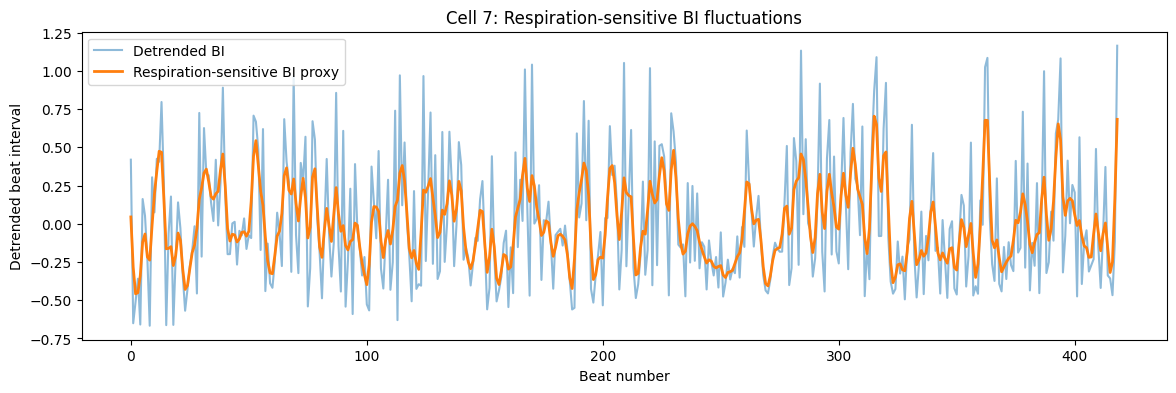

In [99]:
# Cell 7 — Build respiration-sensitive BI fluctuation signal

# BI = beat interval between heartbeats.
# Respiration influences short-timescale HRV
# through respiratory sinus arrhythmia (RSA).
#
# Instead of heavy smoothing, we:
# 1. convert BI to seconds
# 2. remove impossible values
# 3. detrend slow drift
# 4. lightly smooth only slightly
#
# Goal:
# preserve respiration-scale fluctuations (~0.1–0.4 Hz)

from scipy.signal import detrend

# Extract BI values
bi_vals_ms = pd.to_numeric(
    bi[6],
    errors="coerce"
).values

# Convert milliseconds -> seconds
bi_vals_sec = bi_vals_ms / 1000.0

# Remove impossible values
bi_vals_sec = bi_vals_sec[np.isfinite(bi_vals_sec)]

bi_vals_sec = bi_vals_sec[
    (bi_vals_sec > 0.3) &
    (bi_vals_sec < 2.0)
]

# Remove slow drift
bi_detrended = detrend(bi_vals_sec)

# Light smoothing only
# MUCH less smoothing than before
bi_proxy = gaussian_filter1d(
    bi_detrended,
    sigma=1
)

print("Cell 7 complete")

print("Clean BI count:", len(bi_vals_sec))
print("BI min sec:", np.min(bi_vals_sec))
print("BI max sec:", np.max(bi_vals_sec))
print("BI std sec:", np.std(bi_vals_sec))

# Plot
plt.figure(figsize=(14,4))

plt.plot(
    bi_detrended,
    label="Detrended BI",
    alpha=0.5
)

plt.plot(
    bi_proxy,
    label="Respiration-sensitive BI proxy",
    linewidth=2
)

plt.title("Cell 7: Respiration-sensitive BI fluctuations")
plt.xlabel("Beat number")
plt.ylabel("Detrended beat interval")

plt.legend()
plt.show()

Cell 8 complete
EEG duration sec: 534.396
EEG samples: 133600
BI proxy samples: 419
BI-on-EEG samples: 133600


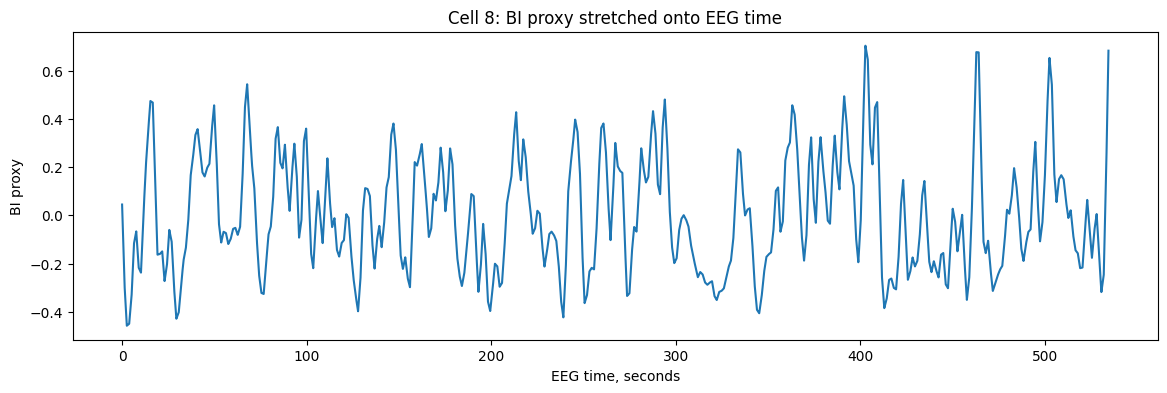

In [100]:
# Cell 8 — Interpolate BI proxy onto EEG sample time

# EEG is sampled regularly at 250 Hz.
# BI is sampled irregularly, once per heartbeat.
# For this first simplified check, we stretch the BI proxy across
# the full EEG recording duration so both signals have the same length.

# This is NOT perfect physiological synchronization.
# It is only a first-pass comparison to check whether slow fluctuations
# look similar across the same recording.

# Create EEG time axis in seconds
eeg_time = np.arange(len(fp1_breath)) / fs_eeg

# Create a simple BI time axis that spans the same duration as EEG
bi_time_stretched = np.linspace(eeg_time[0], eeg_time[-1], len(bi_proxy))

# Interpolate BI proxy onto EEG time
interp_func = interp1d(
    bi_time_stretched,
    bi_proxy,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

bi_on_eeg_time = interp_func(eeg_time)

print("Cell 8 complete")
print("EEG duration sec:", eeg_time[-1])
print("EEG samples:", len(eeg_time))
print("BI proxy samples:", len(bi_proxy))
print("BI-on-EEG samples:", len(bi_on_eeg_time))

plt.figure(figsize=(14, 4))
plt.plot(eeg_time, bi_on_eeg_time)
plt.title("Cell 8: BI proxy stretched onto EEG time")
plt.xlabel("EEG time, seconds")
plt.ylabel("BI proxy")
plt.show()

Cell 9 diagnostics
EEG samples: 133600
BI samples: 133600
Valid paired samples: 133600
EEG std: 1.0
BI std: 0.9999999999999999

Cell 9 result
Zero-lag correlation: r = -0.025, p = 3.49e-20


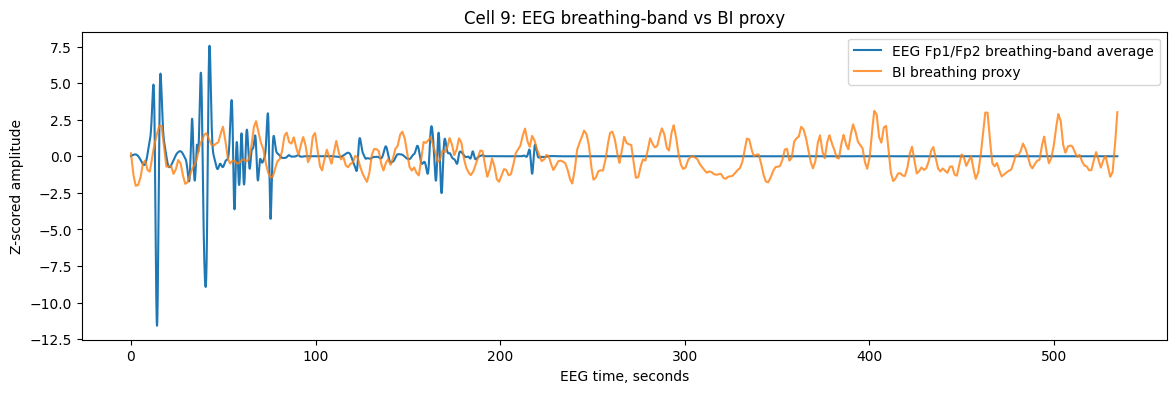

In [101]:
# Cell 9 — Compare EEG breathing-band signal to BI proxy

# This tests whether the simple frontal EEG breathing-band signal
# resembles the BI-derived breathing proxy.

# IMPORTANT:
# We are still NOT using ICA here.
# This is the baseline comparison before ICA.

def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    x[~np.isfinite(x)] = np.nan

    mean = np.nanmean(x)
    std = np.nanstd(x)

    if not np.isfinite(std) or std == 0:
        return np.full_like(x, np.nan)

    return (x - mean) / std


# Simple EEG respiration proxy:
# average the two frontal breathing-band channels
eeg_resp_simple = (fp1_breath + fp2_breath) / 2

# Z-score both signals so they are on the same scale
eeg_resp_z = zscore_safe(eeg_resp_simple)
bi_resp_z = zscore_safe(bi_on_eeg_time)

# Keep only valid paired samples
valid = np.isfinite(eeg_resp_z) & np.isfinite(bi_resp_z)

print("Cell 9 diagnostics")
print("EEG samples:", len(eeg_resp_z))
print("BI samples:", len(bi_resp_z))
print("Valid paired samples:", valid.sum())
print("EEG std:", np.nanstd(eeg_resp_z))
print("BI std:", np.nanstd(bi_resp_z))

if valid.sum() < 2:
    print("\nERROR: Not enough valid paired samples for correlation.")
else:
    r, p = pearsonr(eeg_resp_z[valid], bi_resp_z[valid])

    print("\nCell 9 result")
    print(f"Zero-lag correlation: r = {r:.3f}, p = {p:.3g}")

    plt.figure(figsize=(14, 4))
    plt.plot(eeg_time[valid], eeg_resp_z[valid], label="EEG Fp1/Fp2 breathing-band average")
    plt.plot(eeg_time[valid], bi_resp_z[valid], label="BI breathing proxy", alpha=0.8)
    plt.title("Cell 9: EEG breathing-band vs BI proxy")
    plt.xlabel("EEG time, seconds")
    plt.ylabel("Z-scored amplitude")
    plt.legend()
    plt.show()

In [102]:
# Cell 10 — Load EmotiBit metadata JSON

import json

with open(info_json_path, "r") as f:
    emotibit_info = json.load(f)

print("Cell 10 complete")

print("\nSignals listed in EmotiBit JSON:\n")

for item in emotibit_info:

    info = item.get("info", {})

    name = info.get("name")
    sig_type = info.get("type")
    tags = info.get("typeTags")
    rate = info.get("nominal_srate", "not listed")
    units = info.get("units", "not listed")

    print(
        f"{name} | "
        f"type={sig_type} | "
        f"tags={tags} | "
        f"srate={rate} | "
        f"units={units}"
    )

print("\nLabels actually present in loaded CSV:")
print(sorted(ppg[3].dropna().unique()))

Cell 10 complete

Signals listed in EmotiBit JSON:

EmotiBitData | type=Multimodal | tags=None | srate=not listed | units=not listed
Accelerometer | type=Accelerometer | tags=['AX', 'AY', 'AZ'] | srate=25 | units=g
Gyroscope | type=Gyroscope | tags=['GX', 'GY', 'GZ'] | srate=25 | units=degrees/second
Magnetometer | type=Magnetometer | tags=['MX', 'MY', 'MZ'] | srate=25 | units=microhenries
ElectrodermalActivity | type=ElectrodermalActivity | tags=['EA'] | srate=15 | units=microsiemens
SkinConductanceResponseAmplitude | type=ElectrodermalActivity | tags=['SA'] | srate=not listed | units=microsiemens
SkinConductanceResponseFrequency | type=ElectrodermalActivity | tags=['SF'] | srate=3 | units=count/min
SkinConductanceResponseRiseTime | type=ElectrodermalActivity | tags=['SR'] | srate=not listed | units=secs
Temperature1 | type=Temperature | tags=['T1'] | srate=7.5 | units=degrees celcius
Thermopile | type=Temperature | tags=['TH'] | srate=7.5 | units=degrees celcius
PPG | type=PPG | tags

Creating RawArray with float64 data, n_channels=2, n_times=133600
    Range : 0 ... 133599 =      0.000 ...   534.396 secs
Ready.
Fitting ICA to data using 2 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 0.1s.
Cell 11 complete
ICA sources shape: (2, 133600)


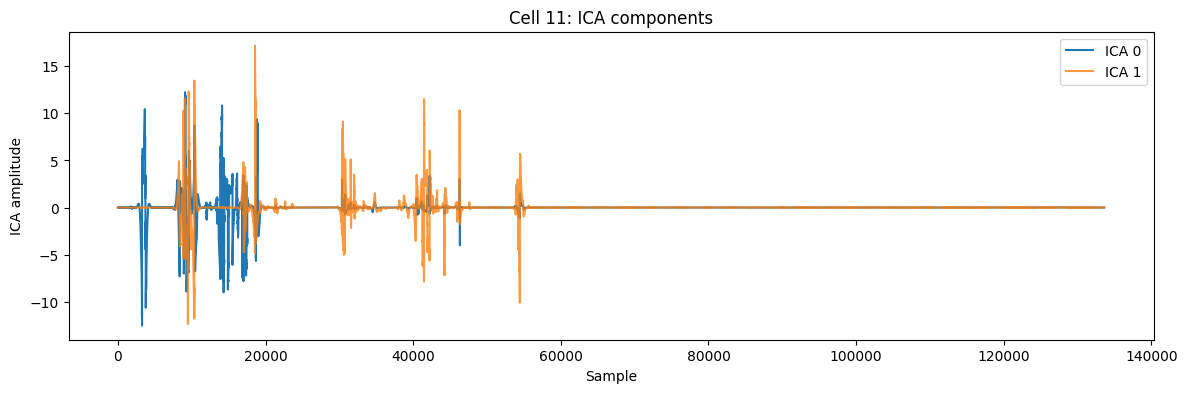

In [103]:
# Cell 11 — Run ICA on cleaned frontal EEG

# ICA attempts to separate mixed EEG activity into components.
#
# With only Fp1 and Fp2 channels:
# - we can only get 2 ICA components
# - components are weighted mixtures of the frontal channels
# - this is exploratory rather than definitive source separation

import mne
from mne.preprocessing import ICA

# Stack channels into MNE format
# shape = channels x samples
eeg_clean_2ch = np.vstack([fp1_clean, fp2_clean])

# Create MNE info structure
info = mne.create_info(
    ch_names=["Fp1", "Fp2"],
    sfreq=fs_eeg,
    ch_types=["eeg", "eeg"]
)

# Create Raw object
raw_clean = mne.io.RawArray(
    eeg_clean_2ch,
    info
)

# ICA should be fit on broader-band EEG,
# not only the respiration band.
raw_for_ica = raw_clean.copy()

raw_for_ica.filter(
    0.5,
    40,
    verbose=False
)

# Run ICA
ica = ICA(
    n_components=2,
    random_state=97,
    max_iter="auto"
)

ica.fit(raw_for_ica)

# Extract ICA component signals
sources_raw = ica.get_sources(raw_for_ica)
sources = sources_raw.get_data()

print("Cell 11 complete")
print("ICA sources shape:", sources.shape)

# Plot ICA components
plt.figure(figsize=(14,4))

plt.plot(sources[0], label="ICA 0")
plt.plot(sources[1], label="ICA 1", alpha=0.8)

plt.title("Cell 11: ICA components")
plt.xlabel("Sample")
plt.ylabel("ICA amplitude")

plt.legend()
plt.show()

Cell 12 results
ICA 0 correlation: r = -0.001, p = 0.622
ICA 1 correlation: r = 0.028, p = 2.16e-25


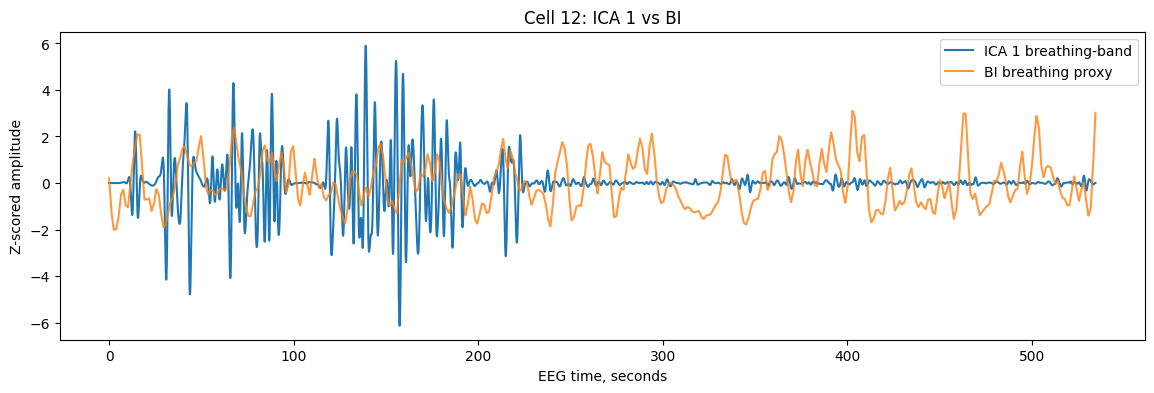

In [104]:
# Cell 12 — Compare ICA components to BI proxy

# This tests whether either ICA component matches the BI-derived breathing proxy
# better than the raw Fp1/Fp2 breathing-band average.

# Extract ICA components
ica0 = sources[0]
ica1 = sources[1]

# Filter ICA components into breathing band
ica0_breath = safe_bandpass(ica0, 0.1, 0.4, fs_eeg)
ica1_breath = safe_bandpass(ica1, 0.1, 0.4, fs_eeg)

# Z-score ICA and BI signals
ica0_z = zscore_safe(ica0_breath)
ica1_z = zscore_safe(ica1_breath)
bi_resp_z = zscore_safe(bi_on_eeg_time)

# Compute correlations
valid0 = np.isfinite(ica0_z) & np.isfinite(bi_resp_z)
valid1 = np.isfinite(ica1_z) & np.isfinite(bi_resp_z)

r0, p0 = pearsonr(ica0_z[valid0], bi_resp_z[valid0])
r1, p1 = pearsonr(ica1_z[valid1], bi_resp_z[valid1])

print("Cell 12 results")
print(f"ICA 0 correlation: r = {r0:.3f}, p = {p0:.3g}")
print(f"ICA 1 correlation: r = {r1:.3f}, p = {p1:.3g}")

# Plot ICA 1 vs BI
plt.figure(figsize=(14,4))

plt.plot(eeg_time, ica1_z, label="ICA 1 breathing-band")
plt.plot(eeg_time, bi_resp_z, label="BI breathing proxy", alpha=0.8)

plt.title("Cell 12: ICA 1 vs BI")
plt.xlabel("EEG time, seconds")
plt.ylabel("Z-scored amplitude")

plt.legend()
plt.show()

Cell 14 complete
Best lag: 0.56 sec
Best correlation: r = 0.035


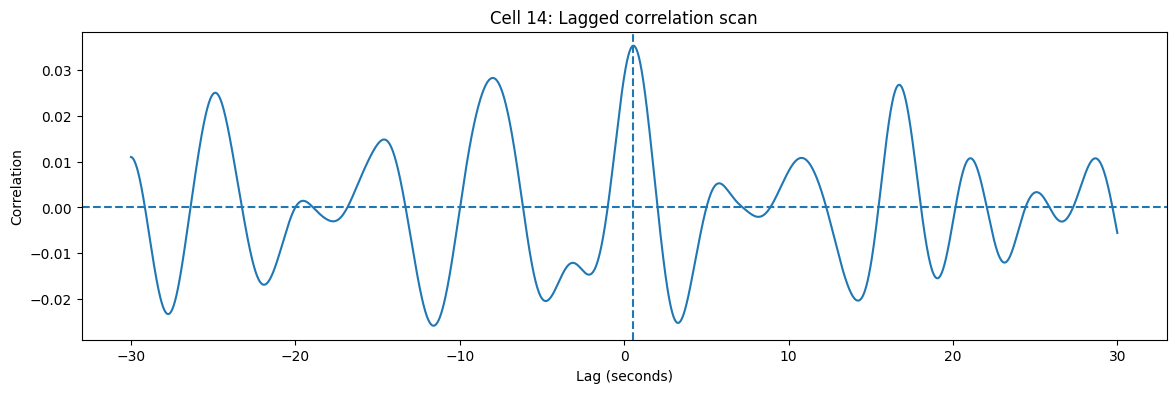

In [105]:
# Cell 14 — Lagged correlation scan between ICA and BI proxy

# This tests whether EEG and BI are related with a time delay.
#
# Positive lag:
# EEG leads BI
#
# Negative lag:
# BI leads EEG

max_lag_sec = 30
max_lag_samples = int(max_lag_sec * fs_eeg)

lags = []
corrs = []

# Use ICA 1 because it was the cleaner-looking component
sig1 = ica1_z
sig2 = bi_resp_z

for lag in range(-max_lag_samples, max_lag_samples):

    if lag < 0:
        x = sig1[:lag]
        y = sig2[-lag:]

    elif lag > 0:
        x = sig1[lag:]
        y = sig2[:-lag]

    else:
        x = sig1
        y = sig2

    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 100:
        corrs.append(np.nan)
        lags.append(lag / fs_eeg)
        continue

    r = np.corrcoef(
        x[valid],
        y[valid]
    )[0,1]

    corrs.append(r)
    lags.append(lag / fs_eeg)

# Convert to arrays
lags = np.array(lags)
corrs = np.array(corrs)

# Best lag
best_idx = np.nanargmax(np.abs(corrs))

best_lag = lags[best_idx]
best_corr = corrs[best_idx]

print("Cell 14 complete")
print(f"Best lag: {best_lag:.2f} sec")
print(f"Best correlation: r = {best_corr:.3f}")

# Plot lag scan
plt.figure(figsize=(14,4))

plt.plot(lags, corrs)

plt.axvline(best_lag, linestyle="--")
plt.axhline(0, linestyle="--")

plt.title("Cell 14: Lagged correlation scan")
plt.xlabel("Lag (seconds)")
plt.ylabel("Correlation")

plt.show()

Fp1/Fp2 average
  Dominant freq: 0.183 Hz
  Breaths/min:   11.0

ICA 0
  Dominant freq: 0.167 Hz
  Breaths/min:   10.0

ICA 1
  Dominant freq: 0.200 Hz
  Breaths/min:   12.0

BI proxy
  Dominant freq: 0.050 Hz
  Breaths/min:   3.0



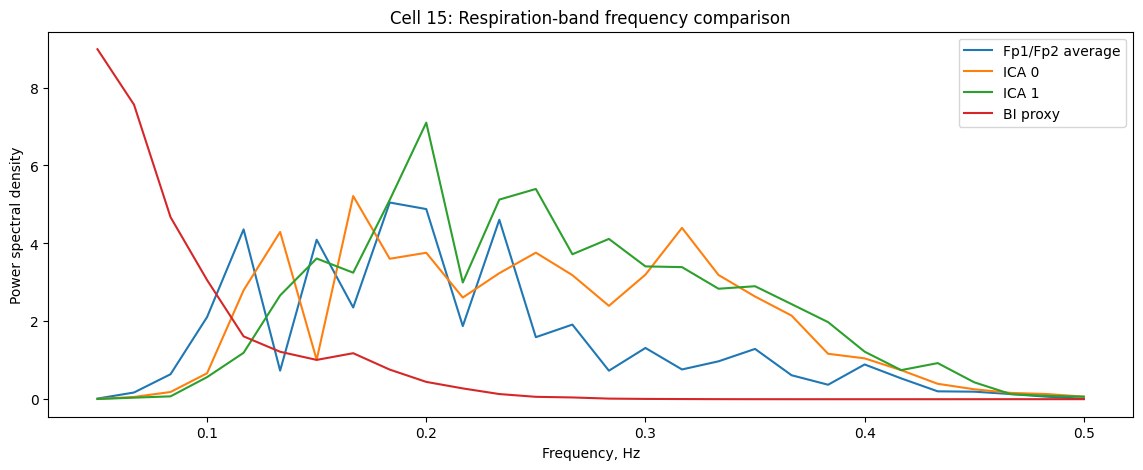

In [106]:
# Cell 15 — Frequency-domain comparison

# This checks whether EEG/ICA and BI have power at similar slow frequencies,
# even if their waveforms do not line up in time.

from scipy.signal import welch

def dominant_freq_in_band(x, fs, fmin=0.05, fmax=0.5):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    freqs, psd = welch(
        x,
        fs=fs,
        nperseg=min(len(x), fs * 60)
    )

    band = (freqs >= fmin) & (freqs <= fmax)

    dom_idx = np.argmax(psd[band])
    dom_freq = freqs[band][dom_idx]
    dom_power = psd[band][dom_idx]

    return freqs, psd, dom_freq, dom_power


# Signals to compare
signals = {
    "Fp1/Fp2 average": eeg_resp_z,
    "ICA 0": ica0_z,
    "ICA 1": ica1_z,
    "BI proxy": bi_resp_z,
}

results = {}

for name, sig in signals.items():
    freqs, psd, dom_freq, dom_power = dominant_freq_in_band(
        sig,
        fs=fs_eeg,
        fmin=0.05,
        fmax=0.5
    )

    results[name] = {
        "freqs": freqs,
        "psd": psd,
        "dom_freq": dom_freq,
        "dom_power": dom_power,
        "breaths_per_min": dom_freq * 60
    }

    print(f"{name}")
    print(f"  Dominant freq: {dom_freq:.3f} Hz")
    print(f"  Breaths/min:   {dom_freq * 60:.1f}")
    print()

plt.figure(figsize=(14, 5))

for name, res in results.items():
    band = (res["freqs"] >= 0.05) & (res["freqs"] <= 0.5)
    plt.plot(
        res["freqs"][band],
        res["psd"][band],
        label=name
    )

plt.title("Cell 15: Respiration-band frequency comparison")
plt.xlabel("Frequency, Hz")
plt.ylabel("Power spectral density")
plt.legend()
plt.show()

Fp1/Fp2 average
  Dominant frequency: 0.183 Hz
  Approx breaths/min: 11.0

ICA 0
  Dominant frequency: 0.167 Hz
  Approx breaths/min: 10.0

ICA 1
  Dominant frequency: 0.200 Hz
  Approx breaths/min: 12.0



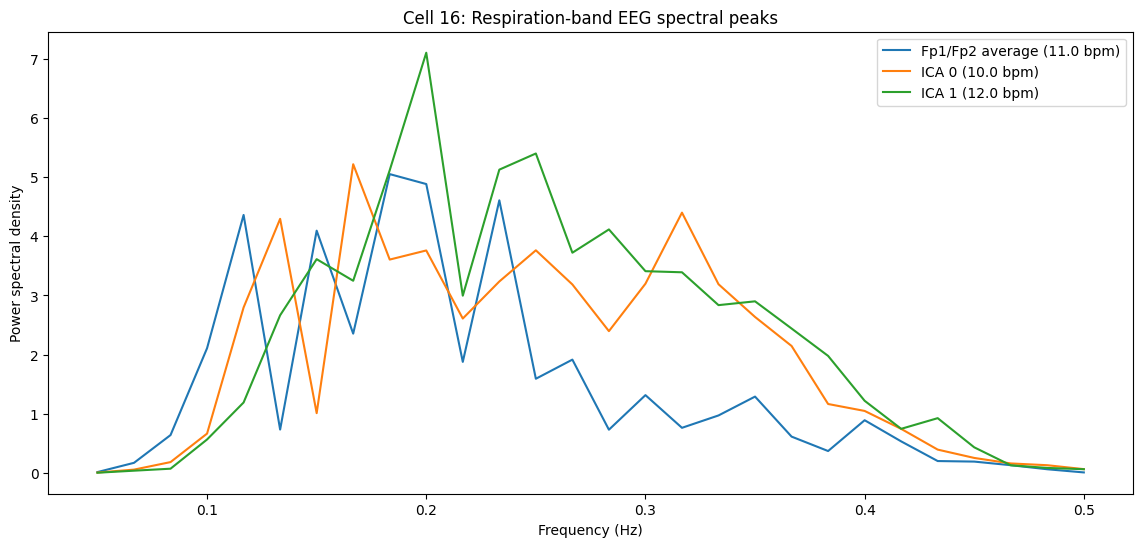

In [107]:
# Cell 16 — Visualize respiration-band EEG spectra

# This visualizes slow oscillatory structure in:
# - frontal EEG average
# - ICA 0
# - ICA 1
#
# We focus on the respiration-relevant frequency range:
# ~0.05–0.5 Hz
#
# Human resting breathing often falls around:
# ~0.1–0.3 Hz
# (~6–18 breaths/min)

from scipy.signal import welch

signals = {
    "Fp1/Fp2 average": eeg_resp_z,
    "ICA 0": ica0_z,
    "ICA 1": ica1_z,
}

plt.figure(figsize=(14,6))

for name, sig in signals.items():

    # Remove NaNs
    sig = sig[np.isfinite(sig)]

    freqs, psd = welch(
        sig,
        fs=fs_eeg,
        nperseg=min(len(sig), fs_eeg * 60)
    )

    # Respiration-band range
    band = (
        (freqs >= 0.05) &
        (freqs <= 0.5)
    )

    # Find dominant peak
    dom_idx = np.argmax(psd[band])

    dom_freq = freqs[band][dom_idx]
    dom_bpm = dom_freq * 60

    print(f"{name}")
    print(f"  Dominant frequency: {dom_freq:.3f} Hz")
    print(f"  Approx breaths/min: {dom_bpm:.1f}")
    print()

    plt.plot(
        freqs[band],
        psd[band],
        label=f"{name} ({dom_bpm:.1f} bpm)"
    )

plt.title("Cell 16: Respiration-band EEG spectral peaks")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")

plt.legend()

plt.show()

# Interpretation checklist

Use this checklist before adding advanced analyses such as:
- PAC
- bycycle
- phase-locking
- cycle-by-cycle coupling
- waveform symmetry metrics

## Signal quality
- Does the EEG remain stable across the recording?
- Are there flat or low-variance sections?
- Are respiration-band filters stable without NaNs or exploding values?

## Respiration-band consistency
- Do Fp1/Fp2 show stable low-frequency oscillations?
- Are dominant EEG spectral peaks within a plausible breathing range (~0.1–0.3 Hz)?

## Physiology comparison
- Do EEG and BI show similar dominant frequencies?
- Do the waveforms visually resemble each other?
- Does lagged correlation improve the relationship?
- Does ICA meaningfully improve the relationship over raw Fp1/Fp2?

## Interpretation caution
- BI is an indirect respiration proxy, not true respiration.
- Weak BI coupling does not necessarily mean EEG lacks respiration-related structure.
- Consumer frontal dry-electrode EEG may contain:
  - respiration-related neural activity
  - motion contamination
  - autonomic coupling
  - vascular or mechanical artifacts

## Before advanced analyses
Only proceed to:
- PAC
- bycycle
- phase analyses
- cycle-by-cycle coupling

after:
- preprocessing is stable
- respiration-band peaks are reproducible
- physiology comparison signals are trustworthy

# Summary

## Dataset

- BrainAccess Halo frontal EEG
  - Fp1
  - Fp2

- EmotiBit physiology export
  - BI
  - HR
  - EDA-related channels
  - metadata indicating PPG capability


## EEG findings

Stable respiration-band oscillations were observed in:

- raw Fp1/Fp2 average
- ICA 0
- ICA 1

Dominant EEG frequencies consistently fell within:

- ~0.16–0.20 Hz
- ~10–12 breaths/min

These frequencies are physiologically plausible for relaxed breathing.


## BI findings

Multiple BI-derived respiration proxy approaches were explored, including:

- smoothed BI fluctuations
- detrended BI fluctuations
- lagged EEG↔BI comparisons
- frequency-domain comparisons

Across approaches:

- zero-lag EEG↔BI correlations remained weak
- lagged correlations also remained weak
- BI-derived dominant frequencies remained slower than the EEG respiration-band peaks

This suggests that BI in this export may not provide a sufficiently direct or reliable respiration estimate for strong EEG coupling analysis.


## ICA findings

ICA did not substantially improve correlation with BI.

However, ICA components preserved respiration-band oscillatory structure similar to the raw frontal EEG average.


## Main interpretation

This notebook demonstrates:

- stable preprocessing of low-density frontal EEG
- reproducible respiration-band EEG oscillations
- successful EEG/physiology alignment pipeline
- limitations of BI-derived respiration estimation in this dataset


## Future directions

Potential improvements include:

- raw PPG waveform export
- direct respiration recordings
- respiration belts
- ECG-derived respiration
- phase-based coupling analyses
- cycle-by-cycle waveform comparisons
- child developmental/regulation analyses